# CELL 1 — INSTALLS

In [1]:

!pip install timm onnx onnxruntime seaborn -q


# CELL 2 — IMPORTS

In [2]:
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import (
Dataset,
DataLoader,
Subset,
WeightedRandomSampler
)

from torchvision import transforms

import timm
from timm.utils import ModelEmaV2

from sklearn.metrics import (
balanced_accuracy_score,
confusion_matrix,
classification_report,
f1_score,
precision_score,
recall_score
)

from sklearn.model_selection import train_test_split

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# CELL 3 — SEED


In [3]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.benchmark = True

seed_everything(42)

# CELL 4 — DEVICE


In [4]:
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)

print("🔥 DEVICE:", device)


🔥 DEVICE: cuda


# CELL 5 — SAVE DIRECTORIES


In [5]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("exports", exist_ok=True)
os.makedirs("metrics", exist_ok=True)

print("✅ Directories Ready")

✅ Directories Ready


# CELL 6 — CLASSES

In [6]:
classes = [
"anger",
"disgust",
"fear",
"happy",
"neutral",
"sad",
"surprise"
]

label_map = {
c:i for i,c in enumerate(classes)
}

num_classes = len(classes)

print(label_map)



{'anger': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# CELL 7 — SAVE LABELS


In [7]:


with open("exports/labels.json", "w") as f:

    json.dump(classes, f)

print("✅ labels.json saved")


✅ labels.json saved


# CELL 8 — DATASET PATHS


In [8]:
BASE = (
"/kaggle/input/datasets/"
"sirguthemen/"
"preprocessed-fed-datset-collection"
)

teacher_root = os.path.join(
BASE,
"preprocessed_teacher_224",
"preprocessed_teacher_224"
)

print("Teacher root:")
print(teacher_root)

print(os.listdir(teacher_root))


Teacher root:
/kaggle/input/datasets/sirguthemen/preprocessed-fed-datset-collection/preprocessed_teacher_224/preprocessed_teacher_224
['Custom', 'KDEF', 'AffectNet', 'FER2013', 'CKPLUS', 'RAF-DB', 'FacialEmotionRecognition']


# CELL 9 — TRANSFORMS

In [9]:

train_teacher_tf = transforms.Compose([

transforms.RandomResizedCrop(
    224,
    scale=(0.75, 1.0)
),

transforms.RandomHorizontalFlip(),

transforms.ColorJitter(
    brightness=0.25,
    contrast=0.25,
    saturation=0.25,
    hue=0.1
),

transforms.RandomRotation(15),

transforms.RandomGrayscale(p=0.05),

transforms.GaussianBlur(
    kernel_size=3
),

transforms.ToTensor(),

transforms.RandomErasing(
    p=0.25
),

transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)


])

train_student_tf = transforms.Compose([


transforms.RandomResizedCrop(
    128,
    scale=(0.75, 1.0)
),

transforms.RandomHorizontalFlip(),

transforms.ColorJitter(
    brightness=0.25,
    contrast=0.25,
    saturation=0.25,
    hue=0.1
),

transforms.RandomRotation(15),

transforms.RandomGrayscale(p=0.05),

transforms.GaussianBlur(
    kernel_size=3
),

transforms.ToTensor(),

transforms.RandomErasing(
    p=0.25
),

transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

])

val_teacher_tf = transforms.Compose([


transforms.Resize((224,224)),

transforms.ToTensor(),

transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

])

val_student_tf = transforms.Compose([

transforms.Resize((128,128)),

transforms.ToTensor(),

transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

])


# CELL 10 — DATASET


In [10]:


class FERDataset(Dataset):

    def __init__(
        self,
        teacher_tf,
        student_tf
    ):

        self.teacher_tf = teacher_tf
        self.student_tf = student_tf

        self.samples = []

        dataset_names = os.listdir(
            teacher_root
        )

        for dataset_name in dataset_names:

            teacher_dataset = os.path.join(
                teacher_root,
                dataset_name
            )

            for emotion in classes:

                emo_folder = os.path.join(
                    teacher_dataset,
                    emotion
                )

                if not os.path.exists(
                    emo_folder
                ):
                    continue

                for fname in os.listdir(
                    emo_folder
                ):

                    if fname.lower().endswith(
                        (
                            ".jpg",
                            ".jpeg",
                            ".png"
                        )
                    ):

                        self.samples.append(
                            (
                                os.path.join(
                                    emo_folder,
                                    fname
                                ),

                                label_map[emotion]
                            )
                        )

        print(
            f"✅ TOTAL IMAGES: "
            f"{len(self.samples)}"
        )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        img = Image.open(
            path
        ).convert("RGB")

        t_img = self.teacher_tf(img)

        s_img = self.student_tf(img)

        return t_img, s_img, label

# CELL 11 — DATASET SPLIT

In [11]:
full_dataset = FERDataset(
train_teacher_tf,
train_student_tf
)

labels = [
s[1]
for s in full_dataset.samples
]

indices = np.arange(len(labels))

train_idx, val_idx = train_test_split(

indices,

test_size=0.2,

stratify=labels,

random_state=42


)

train_ds = Subset(
full_dataset,
train_idx
)

val_full = FERDataset(
val_teacher_tf,
val_student_tf
)

val_ds = Subset(
val_full,
val_idx
)

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))


✅ TOTAL IMAGES: 42342
✅ TOTAL IMAGES: 42342
Train size: 33873
Validation size: 8469


# CELL 12 — BALANCED SAMPLER


In [12]:
train_labels = [
labels[i]
for i in train_idx
]

counts = np.bincount(
train_labels
)

weights = 1.0 / np.sqrt(counts)

sample_weights = [
weights[t]
for t in train_labels
]

sampler = WeightedRandomSampler(
sample_weights,
len(sample_weights),
replacement=True
)

print("Class counts:", counts)



Class counts: [4106 2296 3827 6428 6205 5820 5191]


# CELL 13 — DATALOADERS


In [13]:
train_loader = DataLoader(


train_ds,

batch_size=64,

sampler=sampler,

num_workers=2,

pin_memory=True


)

val_loader = DataLoader(


val_ds,

batch_size=64,

shuffle=False,

num_workers=2,

pin_memory=True


)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))



Train batches: 530
Validation batches: 133


# CELL 14 — MODELS


In [14]:
teacher = timm.create_model(


"convnext_small",

pretrained=True,

num_classes=num_classes


).to(device)

student = timm.create_model(


"tf_efficientnetv2_s",

pretrained=True,

num_classes=num_classes


).to(device)

print("✅ Models Loaded")

✅ Models Loaded


# CELL 15 — FREEZE TEACHER + EMA

In [15]:

for p in teacher.parameters():

    p.requires_grad = False

teacher.eval()

ema = ModelEmaV2(
    student,
    decay=0.999
)

print("✅ Teacher Frozen")
print("✅ EMA Ready")

✅ Teacher Frozen
✅ EMA Ready


# CELL 16 — FEATURE PROJECTOR

In [16]:


class FeatureProjector(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_ch,
                512,
                kernel_size=1
            ),

            nn.BatchNorm2d(512),

            nn.GELU(),

            nn.Conv2d(
                512,
                out_ch,
                kernel_size=1
            )
        )

    def forward(self, x):

        return self.block(x)

# CELL 17 — FEATURE DIMENSIONS

In [17]:

with torch.no_grad():

    dummy_t = torch.randn(
        1,3,224,224
    ).to(device)

    dummy_s = torch.randn(
        1,3,128,128
    ).to(device)

    t_feat = teacher.forward_features(
        dummy_t
    )

    s_feat = student.forward_features(
        dummy_s
    )

t_dim = t_feat.shape[1]
s_dim = s_feat.shape[1]

projector = FeatureProjector(
    s_dim,
    t_dim
).to(device)

print("Teacher dim:", t_dim)
print("Student dim:", s_dim)

Teacher dim: 768
Student dim: 1280


# CELL 18 — FOCAL LOSS

In [18]:


class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2
    ):

        super().__init__()

        self.gamma = gamma

    def forward(
        self,
        logits,
        targets
    ):

        ce = F.cross_entropy(

            logits,

            targets,

            reduction='none',

            label_smoothing=0.1
        )

        pt = torch.exp(-ce)

        loss = (
            (1 - pt) ** self.gamma
        ) * ce

        return loss.mean()

# CELL 19 — KD LOSS

In [19]:

class KDLoss(nn.Module):

    def __init__(
        self,
        T=4.0
    ):

        super().__init__()

        self.T = T

        self.ce = FocalLoss()

    def forward(

        self,

        s_logits,
        t_logits,

        labels,

        s_feat,
        t_feat
    ):

        ce_loss = self.ce(
            s_logits,
            labels
        )

        kd_loss = F.kl_div(

            F.log_softmax(
                s_logits / self.T,
                dim=1
            ),

            F.softmax(
                t_logits / self.T,
                dim=1
            ),

            reduction='batchmean'

        ) * (self.T ** 2)

        s_feat = projector(s_feat)

        t_feat = F.adaptive_avg_pool2d(
            t_feat,
            s_feat.shape[-2:]
        )

        feat_loss = (

            1 -

            F.cosine_similarity(

                s_feat.flatten(1),

                t_feat.flatten(1)

            ).mean()
        )

        total = (

            0.4 * ce_loss +

            0.4 * kd_loss +

            0.2 * feat_loss
        )

        return total

loss_fn = KDLoss()

print("✅ KD Loss Ready")

✅ KD Loss Ready


# CELL 20 — OPTIMIZER

In [20]:
optimizer = optim.AdamW(


list(student.parameters()) +
list(projector.parameters()),

lr=2e-4,

weight_decay=1e-4


)

scheduler = optim.lr_scheduler.CosineAnnealingLR(


optimizer,

T_max=30


)

scaler = torch.amp.GradScaler("cuda")

print("✅ Optimizer Ready")


✅ Optimizer Ready


# CELL 21 — TRAINING

In [21]:

best_acc = 0

epochs = 30

patience = 5
counter = 0

train_losses = []
val_accuracies = []

print("\n🚀 TRAINING STARTED\n")

for epoch in range(epochs):

    student.train()
    projector.train()

    running_loss = 0

    pbar = tqdm(train_loader)

    for t_img, s_img, y in pbar:

        t_img = t_img.to(device)
        s_img = s_img.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            with torch.no_grad():

                t_out = teacher(t_img)

                t_feat = teacher.forward_features(
                    t_img
                )

            s_out = student(s_img)

            s_feat = student.forward_features(
                s_img
            )

            loss = loss_fn(

                s_out,
                t_out,

                y,

                s_feat,
                t_feat
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            student.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        ema.update(student)

        running_loss += loss.item()

        pbar.set_description(

            f"Epoch {epoch+1} "
            f"Loss {loss.item():.4f}"
        )

    scheduler.step()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    ema.module.eval()

    preds = []
    gts = []

    with torch.no_grad():

        for _, s_img, y in val_loader:

            s_img = s_img.to(device)
            y = y.to(device)

            with torch.amp.autocast("cuda"):

                out1 = ema.module(s_img)

                out2 = ema.module(
                    torch.flip(
                        s_img,
                        dims=[3]
                    )
                )

                out = (
                    out1 + out2
                ) / 2

            pred = out.argmax(1)

            preds.extend(
                pred.cpu().numpy()
            )

            gts.extend(
                y.cpu().numpy()
            )

    acc = balanced_accuracy_score(
        gts,
        preds
    ) * 100

    precision = precision_score(
        gts,
        preds,
        average='weighted'
    )

    recall = recall_score(
        gts,
        preds,
        average='weighted'
    )

    weighted_f1 = f1_score(
        gts,
        preds,
        average='weighted'
    )

    macro_f1 = f1_score(
        gts,
        preds,
        average='macro'
    )

    val_accuracies.append(acc)

    print(f"\n📊 Epoch {epoch+1}")

    print(f"Loss: {avg_loss:.4f}")

    print(f"Balanced Accuracy: {acc:.2f}%")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"Weighted F1: {weighted_f1:.4f}")

    print(f"Macro F1: {macro_f1:.4f}")

    
    # SAVE BEST MODEL

    if acc > best_acc:

        best_acc = acc

        counter = 0

        torch.save(

            ema.module.state_dict(),

            "models/best_fer_student.pth"
        )

        print("💾 BEST MODEL SAVED")

    else:

        counter += 1

        print(
            f"⏳ Early Stop Counter: "
            f"{counter}/{patience}"
        )

    
    # EARLY STOPPING


    if counter >= patience:

        print("\n🛑 EARLY STOPPING")
        break

print("\n🏁 TRAINING FINISHED")

print(
    f"\n🏆 BEST ACCURACY:"
    f" {best_acc:.2f}%"
)


🚀 TRAINING STARTED



Epoch 1 Loss 0.5047: 100%|██████████| 530/530 [06:43<00:00,  1.31it/s] 



📊 Epoch 1
Loss: 0.9222
Balanced Accuracy: 19.49%
Precision: 0.2343
Recall: 0.1861
Weighted F1: 0.1511
Macro F1: 0.1438
💾 BEST MODEL SAVED


Epoch 2 Loss 0.4399: 100%|██████████| 530/530 [05:49<00:00,  1.52it/s]



📊 Epoch 2
Loss: 0.5075
Balanced Accuracy: 40.64%
Precision: 0.6181
Recall: 0.4202
Weighted F1: 0.4155
Macro F1: 0.3864
💾 BEST MODEL SAVED


...


📊 Epoch 14
Loss: 0.3620
Balanced Accuracy: 71.43%
Precision: 0.7405
Recall: 0.7354
Weighted F1: 0.7357
Macro F1: 0.7171
⏳ Early Stop Counter: 3/5


Epoch 15 Loss 0.3707: 100%|██████████| 530/530 [05:48<00:00,  1.52it/s]



📊 Epoch 15
Loss: 0.3544
Balanced Accuracy: 71.56%
Precision: 0.7425
Recall: 0.7372
Weighted F1: 0.7377
Macro F1: 0.7184
⏳ Early Stop Counter: 4/5


Epoch 16 Loss 0.3323: 100%|██████████| 530/530 [05:49<00:00,  1.52it/s]



📊 Epoch 16
Loss: 0.3503
Balanced Accuracy: 71.15%
Precision: 0.7383
Recall: 0.7341
Weighted F1: 0.7344
Macro F1: 0.7147
⏳ Early Stop Counter: 5/5

🛑 EARLY STOPPING

🏁 TRAINING FINISHED

🏆 BEST ACCURACY: 72.16%


# CELL 22 — TRAINING CURVES

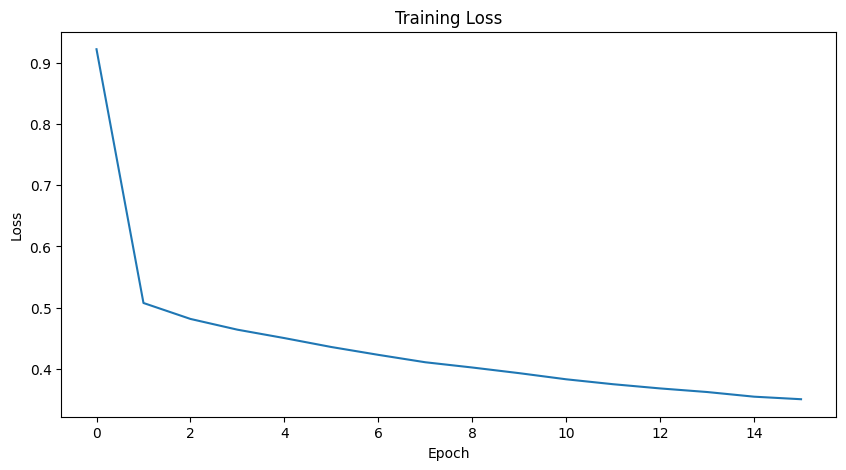

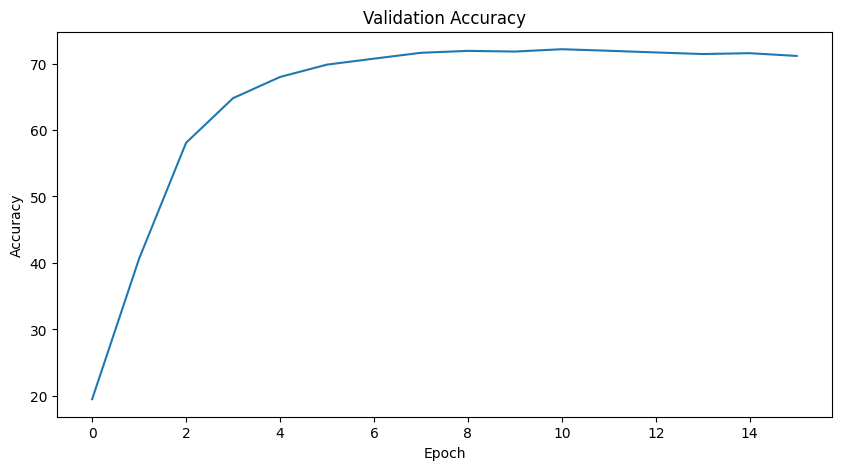

In [22]:


plt.figure(figsize=(10,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.savefig(
    "plots/training_loss.png"
)

plt.show()

plt.figure(figsize=(10,5))

plt.plot(val_accuracies)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig(
    "plots/validation_accuracy.png"
)

plt.show()

# CELL 23 — CONFUSION MATRIX


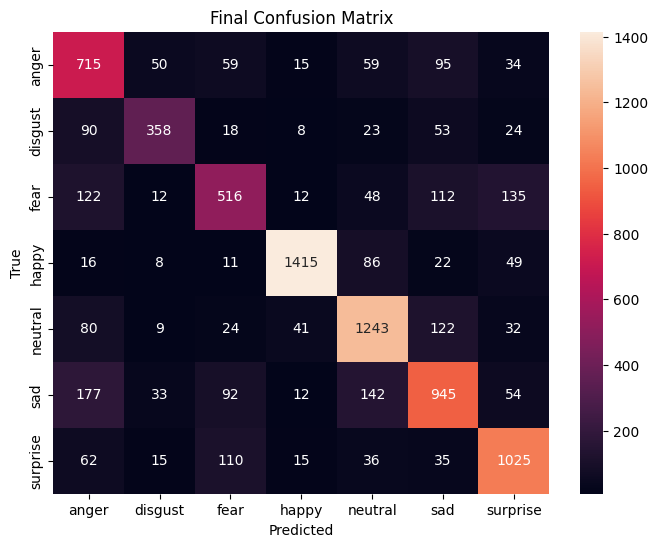

In [23]:

cm = confusion_matrix(
    gts,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=classes,

    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Final Confusion Matrix")

plt.savefig(
    "plots/confusion_matrix.png"
)

plt.show()

# CELL 24 — CLASSIFICATION REPORT

In [24]:


report = classification_report(

    gts,

    preds,

    target_names=classes
)

print(report)

with open(
    "metrics/classification_report.txt",
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

       anger       0.57      0.70      0.62      1027
     disgust       0.74      0.62      0.68       574
        fear       0.62      0.54      0.58       957
       happy       0.93      0.88      0.91      1607
     neutral       0.76      0.80      0.78      1551
         sad       0.68      0.65      0.67      1455
    surprise       0.76      0.79      0.77      1298

    accuracy                           0.73      8469
   macro avg       0.72      0.71      0.71      8469
weighted avg       0.74      0.73      0.73      8469



# CELL 25 — LOAD BEST MODEL


In [25]:

ema.module.load_state_dict(

    torch.load(

        "models/best_fer_student.pth",

        map_location=device
    )
)

ema.module.eval()

print("✅ Best EMA model loaded")

✅ Best EMA model loaded


# CELL 26 — MODEL SIZE

In [26]:


size_mb = os.path.getsize(
    "models/best_fer_student.pth"
) / (1024 * 1024)

print(
    f"📦 Model Size: "
    f"{size_mb:.2f} MB"
)

📦 Model Size: 77.86 MB


# CELL 27 — FPS BENCHMARK


In [27]:

dummy = torch.randn(
    1,
    3,
    128,
    128
).to(device)

# WARMUP

for _ in range(20):

    _ = ema.module(dummy)

torch.cuda.synchronize()

start = time.time()

runs = 200

with torch.no_grad():

    for _ in range(runs):

        _ = ema.module(dummy)

torch.cuda.synchronize()

end = time.time()

total = end - start

fps = runs / total

latency = (total / runs) * 1000

print(f"🚀 FPS: {fps:.2f}")

print(f"⚡ Latency: {latency:.2f} ms")

🚀 FPS: 54.14
⚡ Latency: 18.47 ms


# CELL 28 — EXPORT ONNX


In [28]:

!pip install onnxscript -q

import onnxscript  

dummy = torch.randn(
    1,
    3,
    128,
    128
).to(device)

torch.onnx.export(

    ema.module,

    dummy,

    "exports/best_fer_student.onnx",

    export_params=True,

    opset_version=18,

    do_constant_folding=True,

    input_names=["input"],

    output_names=["output"],

    dynamic_axes={

        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print("✅ ONNX EXPORTED")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 7.8 MB/s eta 0:00:00


W0602 10:51:43.677000 266 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0602 10:51:43.679000 266 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0602 10:51:43.681000 266 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0602 10:51:43.683000 266 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ ONNX EXPORTED


# CELL 29 — VERIFY ONNX

In [29]:

import onnx

model = onnx.load(
    "exports/best_fer_student.onnx"
)

onnx.checker.check_model(model)

print("✅ ONNX MODEL VALID")

✅ ONNX MODEL VALID


# CELL 30 — FINAL FILES

In [30]:

print("\n📁 MODELS:")
print(os.listdir("models"))

print("\n📁 EXPORTS:")
print(os.listdir("exports"))

print("\n📁 PLOTS:")
print(os.listdir("plots"))

print("\n📁 METRICS:")
print(os.listdir("metrics"))


📁 MODELS:
['best_fer_student.pth']

📁 EXPORTS:
['labels.json', 'best_fer_student.onnx', 'best_fer_student.onnx.data']

📁 PLOTS:
['confusion_matrix.png', 'validation_accuracy.png', 'training_loss.png']

📁 METRICS:
['classification_report.txt']
